In [1]:

import sys
import os
sys.path.append('../TCT/')
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT_neighborhood_finder

from TCT import TCT

In [2]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources(use_new_metakg_url=True)

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}


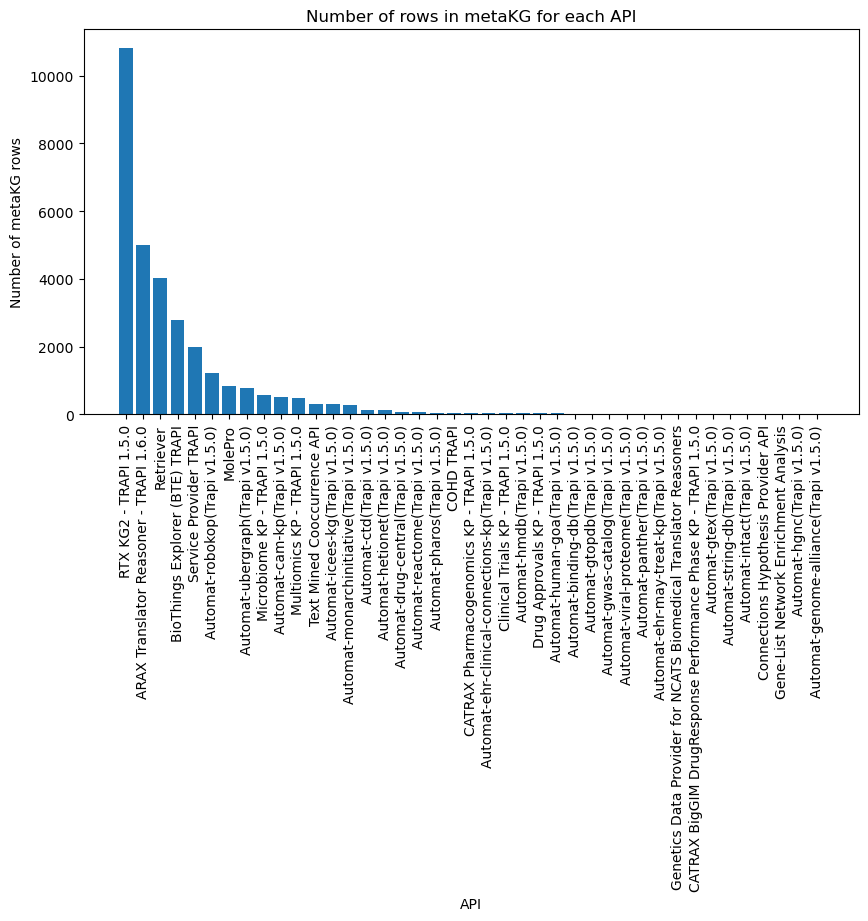

In [3]:

import numpy as np
# calulate how many rows each API has in the metaKG
API_row_count = {}
for api in API_withMetaKG:
    API_row_count[api] = len(metaKG[metaKG['API'] == api])
# sort the API by the number of rows in the metaKG
API_row_count = dict(sorted(API_row_count.items(), key=lambda item: item[1], reverse=True))
API_row_count

# draw a bar chart of the API and the number of rows in the metaKG
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))

plt.bar(API_row_count.keys(), API_row_count.values())
plt.xticks(rotation=90)
plt.xlabel('API')
plt.ylabel('Number of metaKG rows')
plt.title('Number of rows in metaKG for each API')
plt.show()

In [4]:
API_row_count

{'RTX KG2 - TRAPI 1.5.0': 10821,
 'ARAX Translator Reasoner - TRAPI 1.6.0': 5000,
 'Retriever': 4013,
 'BioThings Explorer (BTE) TRAPI': 2778,
 'Service Provider TRAPI': 2000,
 'Automat-robokop(Trapi v1.5.0)': 1233,
 'MolePro': 828,
 'Automat-ubergraph(Trapi v1.5.0)': 776,
 'Microbiome KP - TRAPI 1.5.0': 573,
 'Automat-cam-kp(Trapi v1.5.0)': 529,
 'Multiomics KP - TRAPI 1.5.0': 483,
 'Text Mined Cooccurrence API': 322,
 'Automat-icees-kg(Trapi v1.5.0)': 303,
 'Automat-monarchinitiative(Trapi v1.5.0)': 288,
 'Automat-ctd(Trapi v1.5.0)': 137,
 'Automat-hetionet(Trapi v1.5.0)': 126,
 'Automat-drug-central(Trapi v1.5.0)': 80,
 'Automat-reactome(Trapi v1.5.0)': 73,
 'Automat-pharos(Trapi v1.5.0)': 58,
 'COHD TRAPI': 50,
 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 49,
 'Automat-ehr-clinical-connections-kp(Trapi v1.5.0)': 41,
 'Clinical Trials KP - TRAPI 1.5.0': 39,
 'Automat-hmdb(Trapi v1.5.0)': 35,
 'Drug Approvals KP - TRAPI 1.5.0': 34,
 'Automat-human-goa(Trapi v1.5.0)': 33,
 'Automat-bi

In [11]:
metaKG.loc[(metaKG['API'] == 'Retriever') & (metaKG['Subject'] =='biolink:Cell')].head(60)

,API,Predicate,Subject,Object,URL
13588,Retriever,biolink:interacts_with,biolink:Cell,biolink:CellularComponent,https://retriever.ci.transltr.io/query/
13691,Retriever,biolink:affects,biolink:Cell,biolink:PhenotypicFeature,https://retriever.ci.transltr.io/query/
13765,Retriever,biolink:produces,biolink:Cell,biolink:OrganismTaxon,https://retriever.ci.transltr.io/query/
13921,Retriever,biolink:affects,biolink:Cell,biolink:Activity,https://retriever.ci.transltr.io/query/
13937,Retriever,biolink:interacts_with,biolink:Cell,biolink:MolecularMixture,https://retriever.ci.transltr.io/query/
13940,Retriever,biolink:produces,biolink:Cell,biolink:GenomicEntity,https://retriever.ci.transltr.io/query/
13941,Retriever,biolink:produces,biolink:Cell,biolink:PhenotypicFeature,https://retriever.ci.transltr.io/query/
13979,Retriever,biolink:has_part,biolink:Cell,biolink:ComplexMolecularMixture,https://retriever.ci.transltr.io/query/
14033,Retriever,biolink:has_part,biolink:Cell,biolink:InformationContentEntity,https://retriever.ci.transltr.io/query/
14084,Retriever,biolink:affects,biolink:Cell,biolink:Procedure,https://retriever.ci.transltr.io/query/
